In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

In [60]:
# Load dataset
df = pd.read_csv("Invistico_Airline.csv")

# Basic info
print("Shape of dataset:", df.shape)
print("\nColumn Info:")
print(df.info())

Shape of dataset: (129880, 23)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  

In [61]:
data = df.copy()

# Check missing values BEFORE
print("Missing values BEFORE handling:\n")
print(data.isnull().sum())

# fill missing values
data['Arrival Delay in Minutes'] = data['Arrival Delay in Minutes'].fillna(
    data['Arrival Delay in Minutes'].median()
)

# Check missing values AFTER
print("\nMissing values AFTER handling:\n")
print(data.isnull().sum())


Missing values BEFORE handling:

satisfaction                           0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Seat comfort                           0
Departure/Arrival time convenient      0
Food and drink                         0
Gate location                          0
Inflight wifi service                  0
Inflight entertainment                 0
Online support                         0
Ease of Online booking                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Online boarding                        0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
dtype: int64

Missing va

In [62]:
# Remove extreme delays
data = data[data['Departure Delay in Minutes'] < 1000]
data = data[data['Arrival Delay in Minutes'] < 1000]

# Encode categorical columns
categorical_cols = ['Gender', 'Customer Type', 'Type of Travel', 'Class']

le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

# Encode target variable
data['satisfaction'] = le.fit_transform(data['satisfaction'])

# Features and target
X = data.drop('satisfaction', axis=1)
y = data['satisfaction']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (103900, 22)
Test shape: (25976, 22)


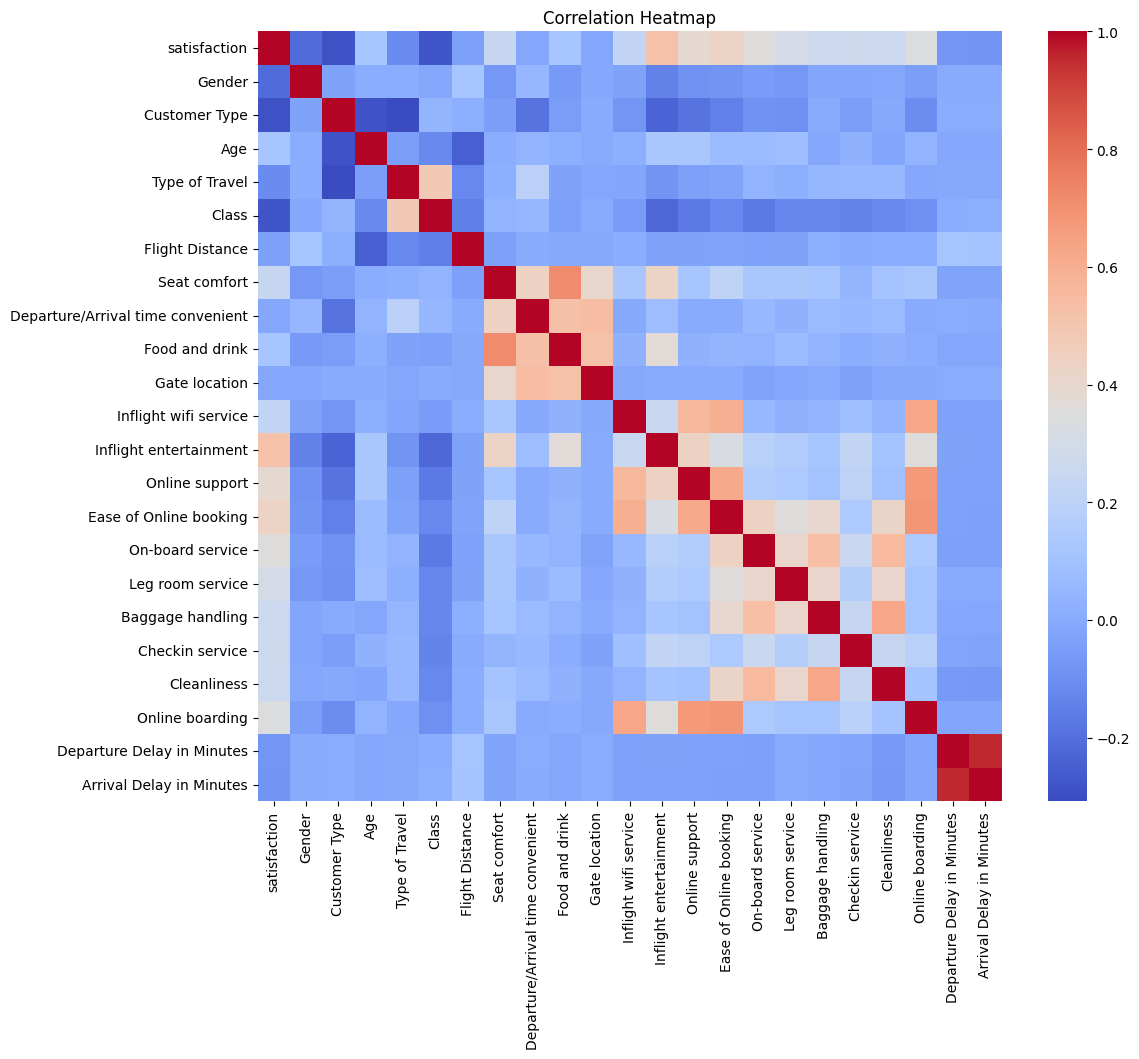

In [63]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

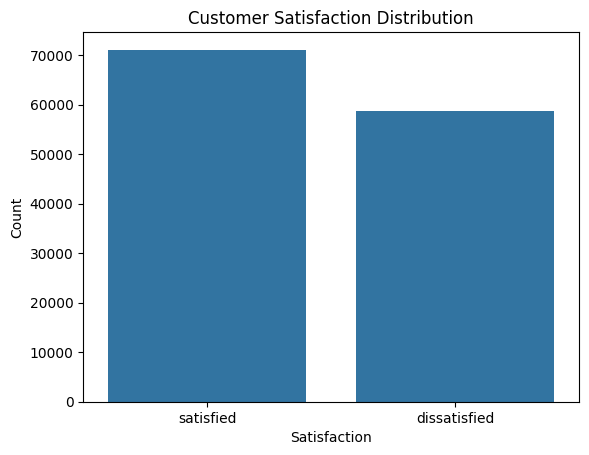

In [64]:
plt.figure()
sns.countplot(x='satisfaction', data=df)
plt.title("Customer Satisfaction Distribution")
plt.xlabel("Satisfaction")
plt.ylabel("Count")
plt.show()

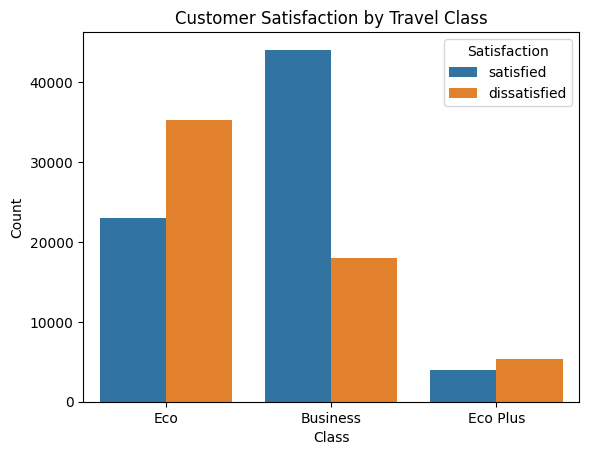

In [65]:
plt.figure()
sns.countplot(x='Class', hue='satisfaction', data=df)
plt.title("Customer Satisfaction by Travel Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(title="Satisfaction")
plt.show()

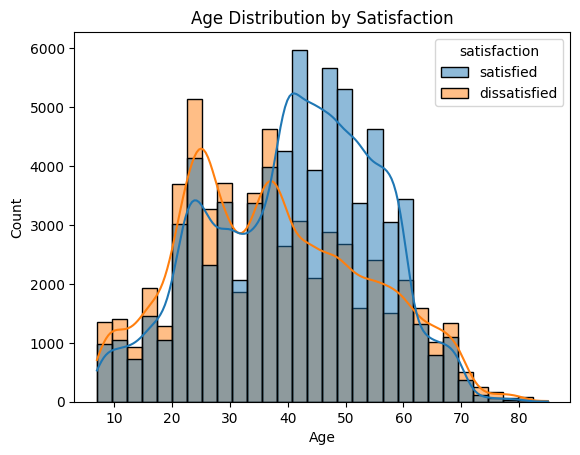

In [66]:
plt.figure()
sns.histplot(data=df, x='Age', hue='satisfaction', bins=30, kde=True)
plt.title("Age Distribution by Satisfaction")
plt.show()

In [67]:
# Model
dt_model = DecisionTreeClassifier(random_state=42)

# Train
dt_model.fit(X_train, y_train)

# Predict
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree trained")

Decision Tree trained


In [68]:
# Model
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting trained")

Gradient Boosting trained


In [69]:
# Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost trained")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:02:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained


In [70]:
# Model
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train
knn_model.fit(X_train, y_train)

# Predict
y_pred_knn = knn_model.predict(X_test)

print("KNN trained")

KNN trained


In [71]:
# Function to evaluate models
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n{model_name}")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


# Evaluating each model
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_gb, "Gradient Boosting")
evaluate_model(y_test, y_pred_xgb, "XGBoost")
evaluate_model(y_test, y_pred_knn, "KNN")


Decision Tree
Accuracy: 0.9377887280566677
Precision: 0.9417373624062259
Recall: 0.9447844130266583
F1 Score: 0.9432584269662921

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93     11759
           1       0.94      0.94      0.94     14217

    accuracy                           0.94     25976
   macro avg       0.94      0.94      0.94     25976
weighted avg       0.94      0.94      0.94     25976


Confusion Matrix:
 [[10928   831]
 [  785 13432]]

Gradient Boosting
Accuracy: 0.9259701262704034
Precision: 0.9309450364554123
Recall: 0.9340226489414082
F1 Score: 0.9324813033250237

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92     11759
           1       0.93      0.93      0.93     14217

    accuracy                           0.93     25976
   macro avg       0.93      0.93      0.93     25976
weighted avg       0.93      0.93   

In [72]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Gradient Boosting', 'XGBoost', 'KNN'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_gb),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_knn)
    ],
    'Precision': [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_knn)
    ],
    'Recall': [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_knn)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_knn)
    ]
})

results.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,XGBoost,0.958962,0.968374,0.956250,0.962273
0,Decision Tree,0.937789,0.941737,0.944784,0.943258
1,Gradient Boosting,0.925970,0.930945,0.934023,0.932481
3,KNN,0.703996,0.724422,0.741085,0.732659


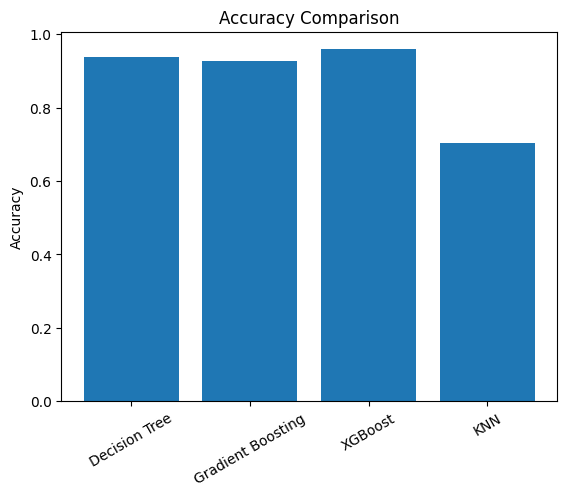

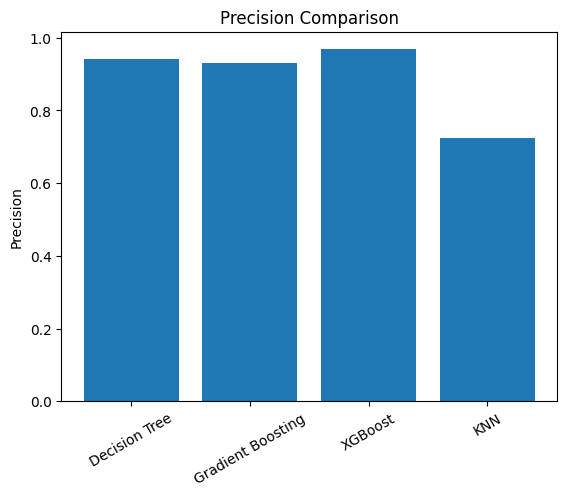

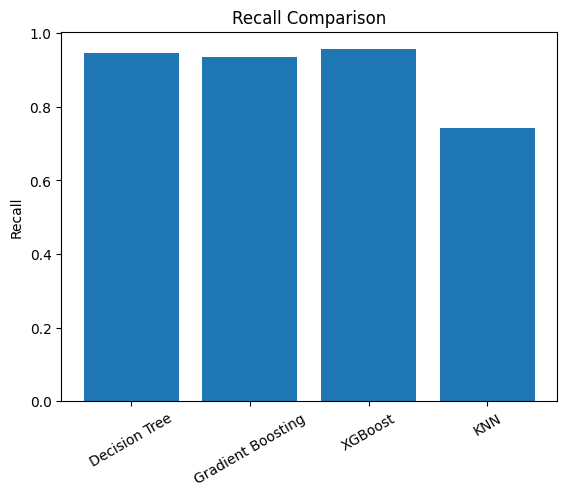

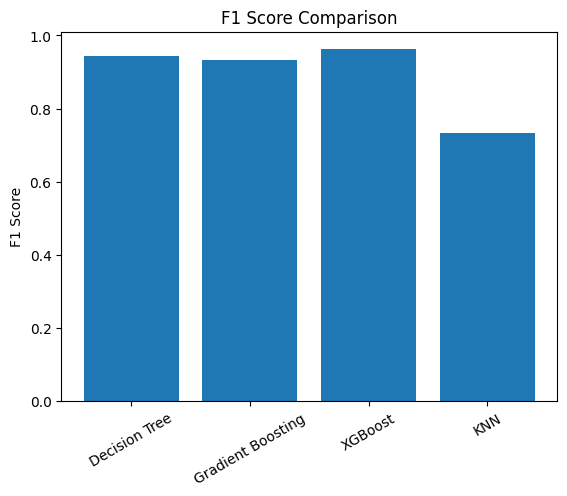

In [73]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric in metrics:
    plt.figure()
    plt.bar(results['Model'], results[metric])
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.show()

In [77]:
import joblib

# Save model
joblib.dump(xgb_model, "xgboost_model.pkl")

# Save label encoder
joblib.dump(le, "label_encoder.pkl")

print("Model saved")

Model saved
